2 Лабораторная работа

Цель - познакомиться с методом кластеризации K-mean с помощью пакета sklearn. 

Для выполнения задания используется набор данных из предыдущей лр.

Что нужно сделать:
1. К текущему датасету необходимо добавить новый аттрибут, например, если есть дата рождения, то посчитать возраст или определить популярность фильма по количеству просмотров и т.п.

2. "Причесать" датасет: удалить выбросы и дубли, обработать пропущенные значения, найти кривые данные и т.п.

3. Построить графики зависимости одной переменной от другой (plt.scatter), описать какие кластеры (группы) вы видите. Построить несколько разных графиков, найти ярковыраженные группы.

4. Изучить перечисленные ноутбуки, по примеру, попробовать применить метод KMeans к вашему датасету (https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html)

https://www.kaggle.com/kushal1996/customer-segmentation-k-means-analysis

https://www.kaggle.com/karthickaravindan/k-means-clustering-project

https://www.kaggle.com/hellbuoy/online-retail-k-means-hierarchical-clustering

https://www.kaggle.com/sirpunch/k-means-clustering

Если ваш датасет не подходит для задачи, его можно поменять. 

5. Написать выводы

Если не установлен sklearn - https://scikit-learn.org/stable/install.html




In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from scipy import stats

df = pd.read_csv('FIFA-21 Complete.csv', sep=';')
df.columns = df.columns.str.strip()

df['growth_potential'] = df['potential'] - df['overall']


In [28]:
# 2 причесывание датасета
numeric_columns = ['age', 'overall', 'potential', 'hits', 'growth_potential']

# Проверка пропусков
print(f"Пропуски до обработки:\n{df[numeric_columns].isnull().sum()}")

# Удаление дубликатов
initial_size = df.shape[0]
df = df.drop_duplicates(subset=['player_id', 'name'])
duplicates_removed = initial_size - df.shape[0]
print(f"Удалено дубликатов: {duplicates_removed}")

# Многомерное удаление выбросов 
def remove_outliers_multivariate(df, columns, threshold=3):
    z_scores = np.abs(stats.zscore(df[columns]))
    mask = (z_scores < threshold).all(axis=1)
    return df[mask]

df_clean = remove_outliers_multivariate(df, numeric_columns)
outliers_removed = df.shape[0] - df_clean.shape[0]
print(f"Удалено выбросов: {outliers_removed}")

Пропуски до обработки:
age                 0
overall             0
potential           0
hits                0
growth_potential    0
dtype: int64
Удалено дубликатов: 0
Удалено выбросов: 414



ПУНКТ 3: Построение графиков зависимости и поиск визуальных кластеров


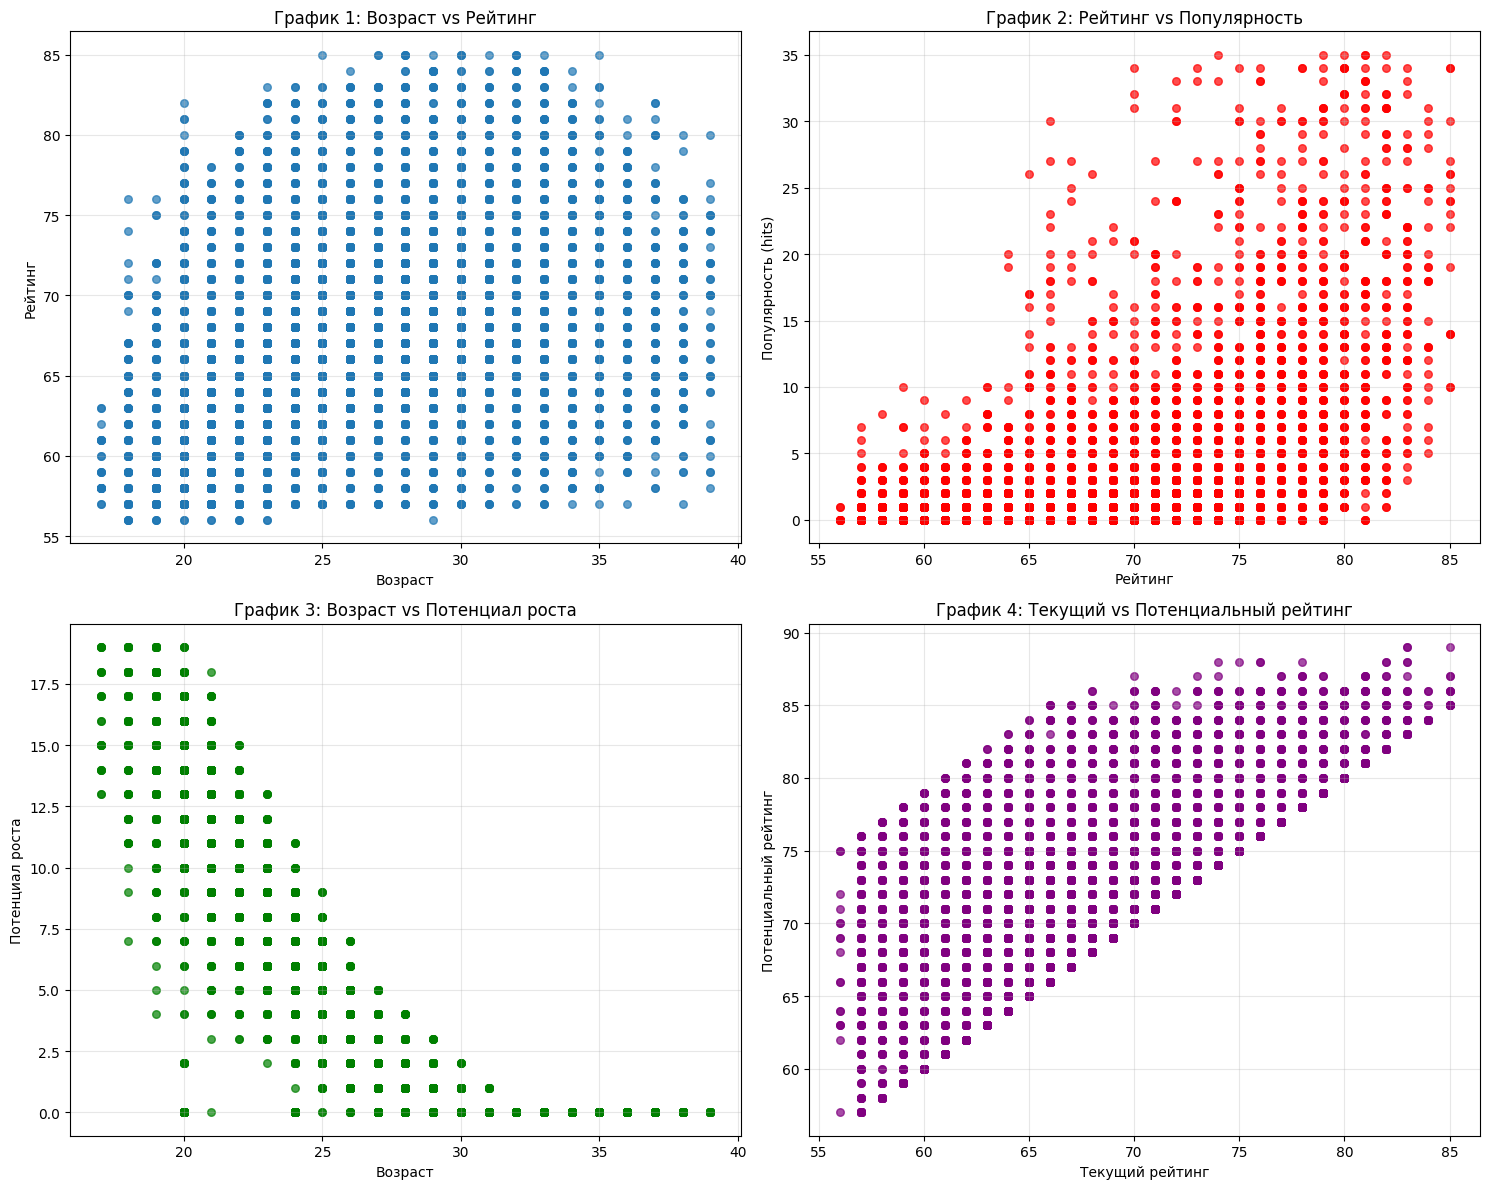

In [23]:
# 3 Построение графиков и поиск кластеров

print("\nПУНКТ 3: Построение графиков зависимости и поиск визуальных кластеров")

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

axes[0,0].scatter(df_clean['age'], df_clean['overall'], alpha=0.7, s=30)
axes[0,0].set_xlabel('Возраст')
axes[0,0].set_ylabel('Рейтинг')
axes[0,0].set_title('График 1: Возраст vs Рейтинг')
axes[0,0].grid(True, alpha=0.3)

axes[0,1].scatter(df_clean['overall'], df_clean['hits'], alpha=0.7, color='red', s=30)
axes[0,1].set_xlabel('Рейтинг')
axes[0,1].set_ylabel('Популярность (hits)')
axes[0,1].set_title('График 2: Рейтинг vs Популярность')
axes[0,1].grid(True, alpha=0.3)

axes[1,0].scatter(df_clean['age'], df_clean['growth_potential'], alpha=0.7, color='green', s=30)
axes[1,0].set_xlabel('Возраст')
axes[1,0].set_ylabel('Потенциал роста')
axes[1,0].set_title('График 3: Возраст vs Потенциал роста')
axes[1,0].grid(True, alpha=0.3)

axes[1,1].scatter(df_clean['overall'], df_clean['potential'], alpha=0.7, color='purple', s=30)
axes[1,1].set_xlabel('Текущий рейтинг')
axes[1,1].set_ylabel('Потенциальный рейтинг')
axes[1,1].set_title('График 4: Текущий vs Потенциальный рейтинг')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Визуальный анализ кластеров показал следующие группы игроков: 
1. молодые перспективные игроки с низким возрастом, средним рейтингом и высоким потенциалом роста 
2. игроки пика карьеры со средним возрастом и высоким рейтингом
3. ветераны с высоким возрастом, хорошим рейтингом и низким потенциалом роста
4. звезды с высоким рейтингом и популярностью


ПУНКТ 4: Применение метода KMeans для автоматической кластеризации


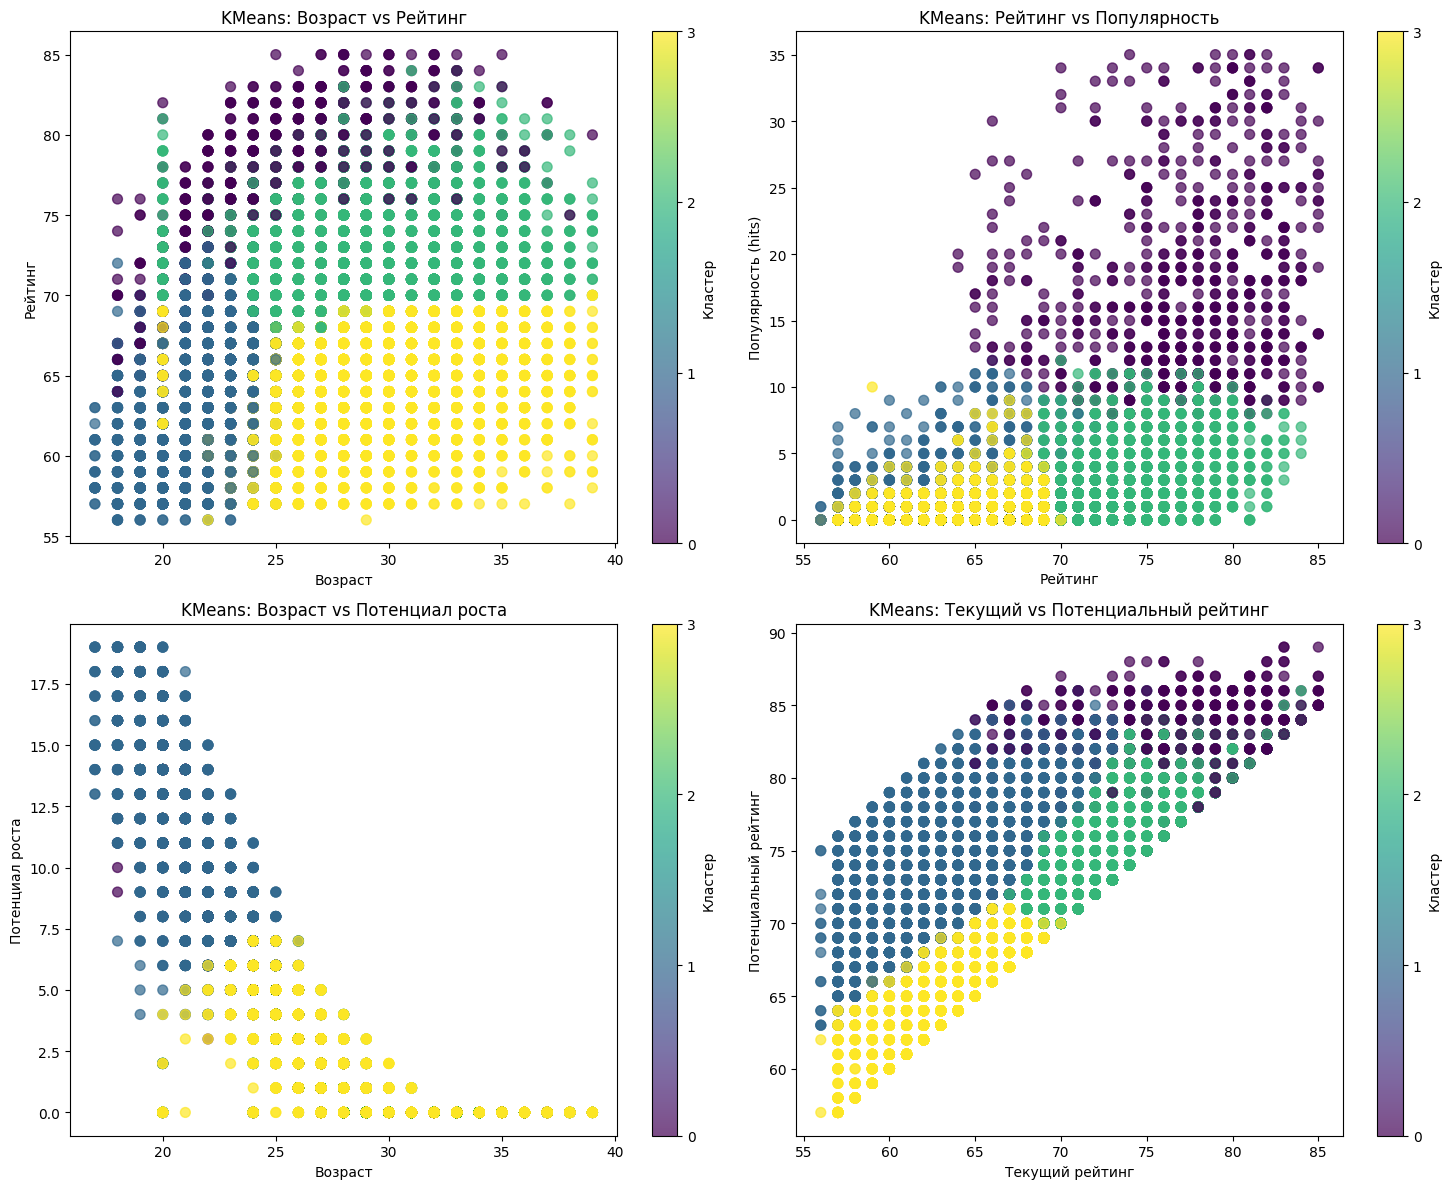

In [35]:
# 4 - Применение метода KMeans
print("\nПУНКТ 4: Применение метода KMeans для автоматической кластеризации")

features = ['age', 'overall', 'potential', 'hits', 'growth_potential']
X = df_clean[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df_clean = df_clean.copy()
df_clean['cluster'] = clusters

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

scatter1 = axes[0,0].scatter(df_clean['age'], df_clean['overall'], c=df_clean['cluster'], cmap='viridis', alpha=0.7, s=50, vmin=0, vmax=optimal_k-1)
axes[0,0].set_xlabel('Возраст')
axes[0,0].set_ylabel('Рейтинг')
axes[0,0].set_title('KMeans: Возраст vs Рейтинг')
cbar1 = plt.colorbar(scatter1, ax=axes[0,0])
cbar1.set_label('Кластер')
cbar1.set_ticks(range(optimal_k))

scatter2 = axes[0,1].scatter(df_clean['overall'], df_clean['hits'], c=df_clean['cluster'], cmap='viridis', alpha=0.7, s=50, vmin=0, vmax=optimal_k-1)
axes[0,1].set_xlabel('Рейтинг')
axes[0,1].set_ylabel('Популярность (hits)')
axes[0,1].set_title('KMeans: Рейтинг vs Популярность')
cbar2 = plt.colorbar(scatter2, ax=axes[0,1])
cbar2.set_label('Кластер')
cbar2.set_ticks(range(optimal_k))

scatter3 = axes[1,0].scatter(df_clean['age'], df_clean['growth_potential'], c=df_clean['cluster'], cmap='viridis', alpha=0.7, s=50, vmin=0, vmax=optimal_k-1)
axes[1,0].set_xlabel('Возраст')
axes[1,0].set_ylabel('Потенциал роста')
axes[1,0].set_title('KMeans: Возраст vs Потенциал роста')
cbar3 = plt.colorbar(scatter3, ax=axes[1,0])
cbar3.set_label('Кластер')
cbar3.set_ticks(range(optimal_k))

scatter4 = axes[1,1].scatter(df_clean['overall'], df_clean['potential'], c=df_clean['cluster'], cmap='viridis', alpha=0.7, s=50, vmin=0, vmax=optimal_k-1)
axes[1,1].set_xlabel('Текущий рейтинг')
axes[1,1].set_ylabel('Потенциальный рейтинг')
axes[1,1].set_title('KMeans: Текущий vs Потенциальный рейтинг')
cbar4 = plt.colorbar(scatter4, ax=axes[1,1])
cbar4.set_label('Кластер')
cbar4.set_ticks(range(optimal_k))

plt.tight_layout()
plt.show()

In [33]:
# 5 - Выводы
print("\nПУНКТ 5: ВЫВОДЫ")

print("\nХАРАКТЕРИСТИКИ КЛАСТЕРОВ:")
for i in range(optimal_k):
    cluster_data = df_clean[df_clean['cluster'] == i]
    print(f"\n Кластер {i} (игроков: {len(cluster_data)}) ")
    print(f"• Средний возраст: {cluster_data['age'].mean():.1f} лет")
    print(f"• Средний рейтинг: {cluster_data['overall'].mean():.1f}")
    print(f"• Средний потенциал: {cluster_data['potential'].mean():.1f}")
    print(f"• Средняя популярность: {cluster_data['hits'].mean():.0f} hits")
    print(f"• Средний потенциал роста: {cluster_data['growth_potential'].mean():.1f}")

print(f". Итоговый датасет содержит {len(df_clean)} игроков, разделенных на {optimal_k} стратегические группы")



ПУНКТ 5: ВЫВОДЫ

ХАРАКТЕРИСТИКИ КЛАСТЕРОВ:

 Кластер 0 (игроков: 765) 
• Средний возраст: 25.0 лет
• Средний рейтинг: 77.0
• Средний потенциал: 82.4
• Средняя популярность: 17 hits
• Средний потенциал роста: 5.4

 Кластер 1 (игроков: 5692) 
• Средний возраст: 21.7 лет
• Средний рейтинг: 63.3
• Средний потенциал: 73.5
• Средняя популярность: 1 hits
• Средний потенциал роста: 10.2

 Кластер 2 (игроков: 5053) 
• Средний возраст: 28.6 лет
• Средний рейтинг: 72.8
• Средний потенциал: 74.3
• Средняя популярность: 2 hits
• Средний потенциал роста: 1.5

 Кластер 3 (игроков: 6057) 
• Средний возраст: 29.0 лет
• Средний рейтинг: 64.6
• Средний потенциал: 65.7
• Средняя популярность: 0 hits
• Средний потенциал роста: 1.1
. Итоговый датасет содержит 17567 игроков, разделенных на 4 стратегические группы


KMeans выделил 4 кластера игроков с различными характеристиками. Кластеры соответствуют естественным группам: звезды (кластер 0), молодые таланты (кластер 1), игроки пика карьеры (кластер 2), ветераны со средним рейтингом (кластер 3). Потенциал роста обратно пропорционален возрасту - молодые игроки имеют больше возможностей для роста. Популярность сильно коррелирует с рейтингом - лучшие игроки получают больше внимания.




























